# Model Deployment
(Date - 1/Aug/2026)

## 0. Necessary Imports

In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt
from torch import nn
from torchvision import transforms, datasets
from helper_functions import download_data, set_seeds, plot_loss_curves
from torchinfo import summary
from going_modular import data_setup, engine, utils
from pathlib import Path
from PIL import Image
from timeit import default_timer as timer 
from tqdm.auto import tqdm
from typing import List, Dict, Tuple
import pandas as pd
import random
import gradio as gr
import shutil
from IPython.display import IFrame

device = "cuda" if torch.cuda.is_available() else "cpu"
device

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'cpu'

## 1. Getting the data ready

In [2]:
data_20_percent_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
                                     destination="pizza_steak_sushi_20_percent")

data_20_percent_path                   

[INFO] data\pizza_steak_sushi_20_percent directory exists, skipping download.


WindowsPath('data/pizza_steak_sushi_20_percent')

In [3]:
train_dir = str(data_20_percent_path / "train")
test_dir = str(data_20_percent_path / "test")

train_dir, test_dir

('data\\pizza_steak_sushi_20_percent\\train',
 'data\\pizza_steak_sushi_20_percent\\test')

## 2. Recreating Effnet B2

(Date - 2/Aug/2026)

In [4]:
effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
effnetb2_transforms = effnetb2_weights.transforms()
effnetb2 = torchvision.models.efficientnet_b2(weights=effnetb2_weights)

for params in effnetb2.parameters():
    params.requires_grad = False

In [5]:
effnetb2.classifier

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1408, out_features=1000, bias=True)
)

In [6]:
effnetb2.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(in_features=1408,
              out_features=3,
              bias=True)
)

In [7]:
effnetb2.classifier

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1408, out_features=3, bias=True)
)

### 2.1 Making a function to reproduce our model

In [8]:
def create_effnetb2(num_classes:int=3,
                    seed:int=42):
    """Creates an EfficientNetB2 feature extractor model and transforms.

    Args:
        num_classes (int, optional): number of classes in the classifier head. 
            Defaults to 3.
        seed (int, optional): random seed value. Defaults to 42.

    Returns:
        model (torch.nn.Module): EffNetB2 feature extractor model. 
        transforms (torchvision.transforms): EffNetB2 image transforms.
    """
    effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms = effnetb2_weights.transforms()
    model = torchvision.models.efficientnet_b2(weights=effnetb2_weights)

    for params in model.parameters():
        params.requires_grad = False

    torch.manual_seed(seed)
    model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(in_features=1408,
              out_features=num_classes,
              bias=True)
    )

    return model, transforms

In [9]:
test_model, test_transforms = create_effnetb2()
test_model, test_transforms

(EfficientNet(
   (features): Sequential(
     (0): Conv2dNormActivation(
       (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
       (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
       (2): SiLU(inplace=True)
     )
     (1): Sequential(
       (0): MBConv(
         (block): Sequential(
           (0): Conv2dNormActivation(
             (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
             (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
             (2): SiLU(inplace=True)
           )
           (1): SqueezeExcitation(
             (avgpool): AdaptiveAvgPool2d(output_size=1)
             (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
             (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
             (activation): SiLU(inplace=True)
             (scale_activation): Sigmoid()
 

In [10]:
summary(model=test_model, 
        input_size=(1, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

### 2.2 Making the dataloaders ready!

In [11]:
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                               test_dir=test_dir,
                                                                               train_transform=effnetb2_transforms,
                                                                               test_transform=effnetb2_transforms,
                                                                               batch_size=32)

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x1d56c979490>,
 ['pizza', 'steak', 'sushi'])

### 2.3 Training our effnetb2 model

In [12]:
optimizer = torch.optim.Adam(params=effnetb2.parameters(),
                             lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
effnetb2_results = engine.train(model=effnetb2,
                             train_dataloader=train_dataloader,
                             test_dataloader=test_dataloader,
                             optimizer=optimizer,
                             loss_fn=loss_fn,
                             epochs=1,
                             device=device,
                             )

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [01:32<00:00, 92.91s/it]

Epoch: 1 | train_loss: 0.9530 | train_acc: 0.5979 | test_loss: 0.7113 | test_acc: 0.9068


### 2.4 Plotting the loss curves

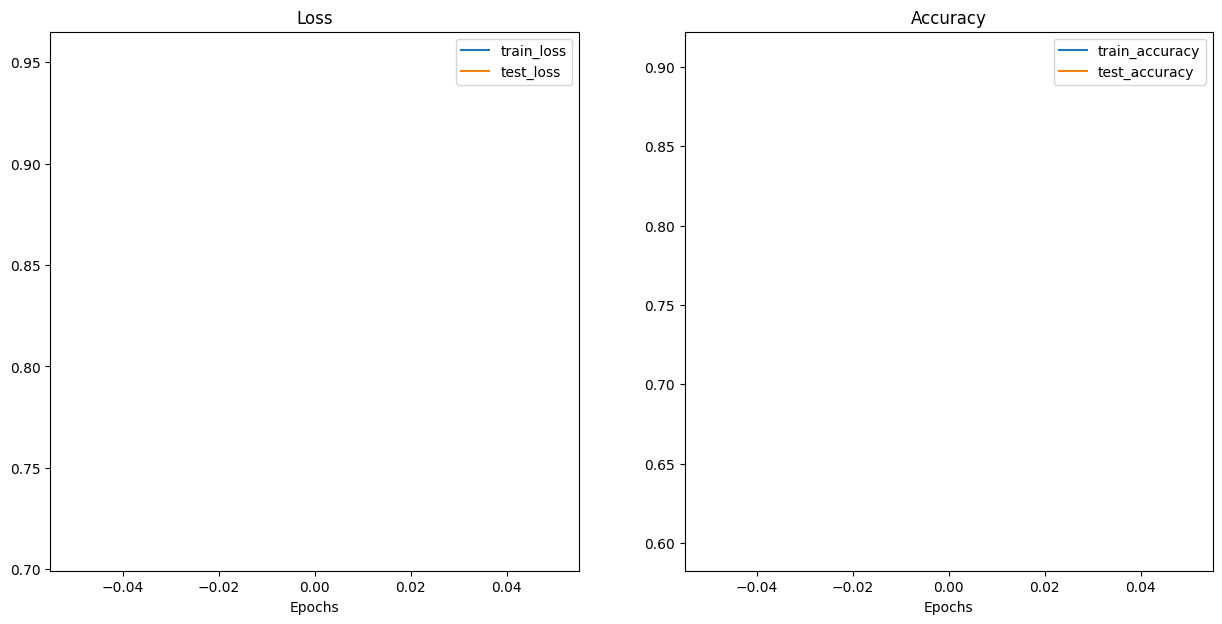

In [13]:
plot_loss_curves(effnetb2_results)

### 2.5 Saving our effnetB2 feature extractor

In [14]:
# utils.save_model(model=effnetb2,
#                  target_dir="../models",
#                  model_name="9_effnetb2_feature_extractor.pth")

### 2.6 Checking our model's size

In [15]:
model_stats = Path("../models/9_effnetb2_feature_extractor.pth").stat()
model_stats

os.stat_result(st_mode=33206, st_ino=1970324836981508, st_dev=4076179428, st_nlink=1, st_uid=0, st_gid=0, st_size=31278385, st_atime=1787057469, st_mtime=1785771125, st_ctime=1785770046)

In [16]:
model_size_in_bytes = model_stats.st_size
model_size_in_bytes

31278385

In [17]:
effnetb2_size_in_mb = model_size_in_bytes // (1024*1024)
print(f"Model size (roughly) in MB: {effnetb2_size_in_mb} MB")

Model size (roughly) in MB: 29 MB


### 2.7 Preparing our model's stats

In [18]:
a = torch.zeros(4,4)
a

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [19]:
torch.numel(a) # Returns the total number of elements in the input tensor

16

In [20]:
for param in effnetb2.parameters():
    temporary_param = param
    break

# temporary_param

In [21]:
torch.numel(temporary_param)

864

In [22]:
effnetb2_total_params = 0
for param in effnetb2.parameters():
    effnetb2_total_params += torch.numel(param)

effnetb2_total_params

7705221

In [23]:
effnetb2_results

{'train_loss': [0.9529865145683288],
 'train_acc': [0.5979166666666667],
 'test_loss': [0.711309552192688],
 'test_acc': [0.9068181818181819]}

In [24]:
effnetb2_stats = {"test_loss":effnetb2_results["test_loss"][-1],
                  "test_acc":effnetb2_results["test_acc"][-1],
                  "total_params":effnetb2_total_params,
                  "model_size (MB)":effnetb2_size_in_mb}

effnetb2_stats

{'test_loss': 0.711309552192688,
 'test_acc': 0.9068181818181819,
 'total_params': 7705221,
 'model_size (MB)': 29}

## 4. Creating our ViT feature extractor

In [25]:
vit = torchvision.models.vit_b_16()
vit

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine

In [26]:
weights = torchvision.models.ViT_B_16_Weights.DEFAULT
transforms = weights.transforms()
model = torchvision.models.vit_b_16(weights=weights)

for param in model.parameters():
    param.requires_grad = False

set_seeds(42)
model.heads = nn.Sequential(
    nn.Linear(in_features=768,
                out_features=3)
)

In [27]:
def create_vit(num_classes:int=3,
               seed:int=42):
    """Creates a ViT-B/16 feature extractor model and transforms.

    Args:
        num_classes (int, optional): number of target classes. Defaults to 3.
        seed (int, optional): random seed value for output layer. Defaults to 42.

    Returns:
        model (torch.nn.Module): ViT-B/16 feature extractor model. 
        transforms (torchvision.transforms): ViT-B/16 image transforms.
    """
    weights = torchvision.models.ViT_B_16_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.vit_b_16(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    set_seeds(seed)
    model.heads = nn.Sequential(
        nn.Linear(in_features=768,
                  out_features=num_classes)
    )

    return model, transforms

In [28]:
vit, vit_transforms = create_vit()

In [29]:
# Print ViT feature extractor model summary (uncomment for full output)
summary(vit, 
        input_size=(1, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 224, 224]     [1, 3]               768                  Partial
├─Conv2d (conv_proj)                                         [1, 3, 224, 224]     [1, 768, 14, 14]     (590,592)            False
├─Encoder (encoder)                                          [1, 197, 768]        [1, 197, 768]        151,296              False
│    └─Dropout (dropout)                                     [1, 197, 768]        [1, 197, 768]        --                   --
│    └─Sequential (layers)                                   [1, 197, 768]        [1, 197, 768]        --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 197, 768]        [1, 197, 768]        (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 197, 768]        [1, 1

### 4.1 Creating the dataloaders

In [30]:
train_dataloader_vit, test_dataloader_vit, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                               test_dir=test_dir,
                                                                               train_transform=transforms,
                                                                               test_transform=transforms,
                                                                               batch_size=32)
train_dataloader_vit, test_dataloader_vit, class_names


(<torch.utils.data.dataloader.DataLoader at 0x1d5f6f20850>,
 ['pizza', 'steak', 'sushi'])

### 4.2 Training our ViT feature extractor

(Date - 4/Aug/2026)

In [31]:
# Setup optimizer
optimizer = torch.optim.Adam(params=vit.parameters(),
                             lr=1e-3)
# Setup loss function
loss_fn = torch.nn.CrossEntropyLoss()

# Train ViT model with seeds set for reproducibility
set_seeds()
vit_results = engine.train(model=vit,
                           train_dataloader=train_dataloader_vit,
                           test_dataloader=test_dataloader_vit,
                           epochs=1,
                           optimizer=optimizer,
                           loss_fn=loss_fn,
                           device=device)

100%|██████████| 1/1 [03:55<00:00, 235.87s/it]

Epoch: 1 | train_loss: 0.7020 | train_acc: 0.7521 | test_loss: 0.2714 | test_acc: 0.9381


### 4.3 Plotting the loss curves
(Date - 5/Aug/2026)

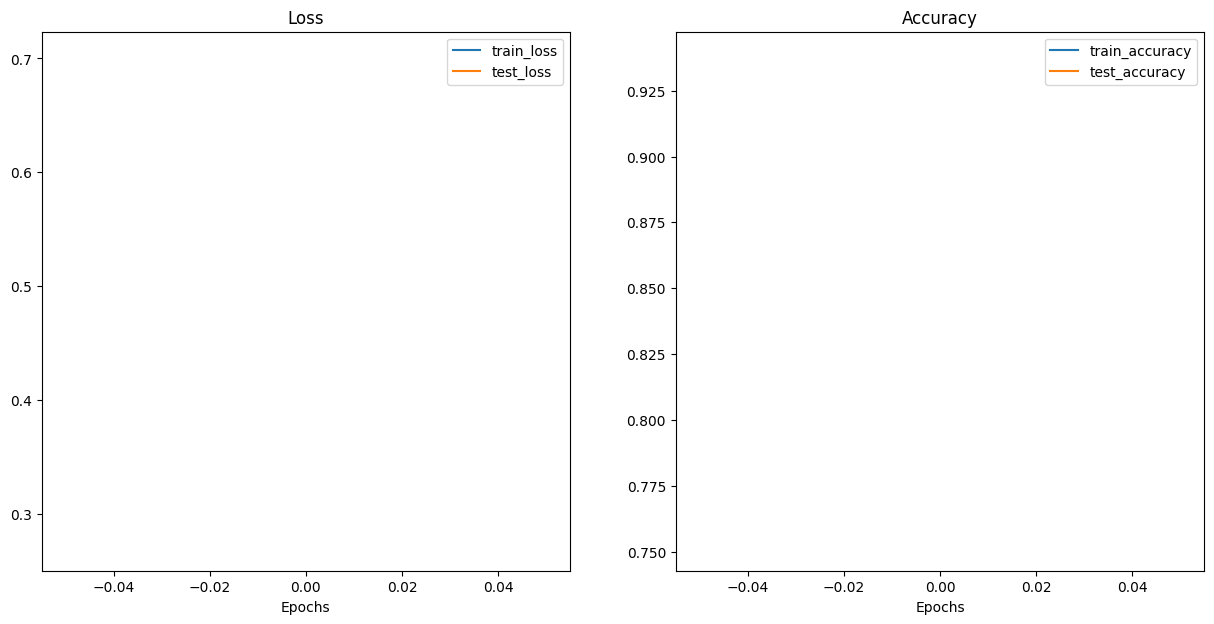

In [32]:
plot_loss_curves(vit_results)

### 4.4 Saving our ViT feature extractor
(Date - 6/Aug/2026)

In [33]:
utils.save_model(model=vit,
                 target_dir="../models",
                 model_name="09_ViT.pth")

[INFO] Saving model to: ..\models\09_ViT.pth


### 4.5 Checking the size of our ViT feature extractor

In [34]:
pretrained_vit_model_size = Path("../models/09_ViT.pth").stat().st_size // (1024*1024) # division converts bytes to megabytes (roughly) 
print(f"Pretrained ViT feature extractor model size: {pretrained_vit_model_size} MB")

Pretrained ViT feature extractor model size: 327 MB


### 4.6 Collecting ViT feature extractor stats

In [35]:
vit_total_params = sum(torch.numel(param) for param in vit.parameters())
vit_total_params

85800963

In [36]:
vit_stats = {"test_loss":vit_results["test_loss"][-1],
             "test_acc":vit_results["test_acc"][-1],
             "total_params":vit_total_params,
             "model_size (MB)":pretrained_vit_model_size}

vit_stats

{'test_loss': 0.2713924080133438,
 'test_acc': 0.9380681818181819,
 'total_params': 85800963,
 'model_size (MB)': 327}

## 5. Making predictions with our model and timing them

(Date - 7/Aug/2026)

In [37]:
print(f"[INFO] Finding all filepaths ending with '.jpg' in directory: {test_dir}")
test_data_paths = list(Path(test_dir).glob("*/*.jpg"))
test_data_paths[:5]

[INFO] Finding all filepaths ending with '.jpg' in directory: data\pizza_steak_sushi_20_percent\test


[WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1001116.jpg'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1032754.jpg'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1067986.jpg'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/129666.jpg'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1315645.jpg')]

### 5.1 Creating a function

In [38]:
def pred_and_store(paths:List[Path],
                model:torch.nn.Module,
                transform:torchvision.transforms,
                class_names:List[str],
                device = "cuda" if torch.cuda.is_available() else "cpu"):
    pred_list = []
    for path in tqdm(paths):
        pred_dict = {}
        pred_dict["image_path"] = path
        class_name = path.parent.stem
        pred_dict["class_name"] = class_name

        start_time = timer()

        img = Image.open(path)
        transformed_image = transform(img).unsqueeze(0).to(device)

        model.to(device)
        model.eval()

        with torch.inference_mode():
            pred_logit = model(transformed_image)
            pred_prob = torch.softmax(pred_logit, dim=1)
            pred_label = torch.argmax(pred_prob, dim=1)
            pred_class = class_names[pred_label.cpu()]

            pred_dict["pred_prob"] = round(pred_prob.unsqueeze(0).max().cpu().item(), 4)
            pred_dict["pred_class"] = pred_class

            end_time = timer()
            pred_dict["time_for_pred"] = round(end_time-start_time, 4)

        pred_dict["correct"] = class_name == pred_class
        pred_list.append(pred_dict)

    return pred_list


In [39]:
# Make predictions across test dataset with EffNetB2
effnetb2_test_pred_dicts = pred_and_store(paths=test_data_paths,
                                          model=effnetb2,
                                          transform=effnetb2_transforms,
                                          class_names=class_names,
                                          device="cpu") # make predictions on CPU 

100%|██████████| 150/150 [00:22<00:00,  6.61it/s]


In [40]:
# Inspect the first 2 prediction dictionaries
effnetb2_test_pred_dicts[:2]

[{'image_path': WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1001116.jpg'),
  'class_name': 'pizza',
  'pred_prob': 0.5956,
  'pred_class': 'pizza',
  'time_for_pred': 0.2967,
  'correct': True},
 {'image_path': WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1032754.jpg'),
  'class_name': 'pizza',
  'pred_prob': 0.3669,
  'pred_class': 'sushi',
  'time_for_pred': 0.1868,
  'correct': False}]

In [41]:
len(effnetb2_test_pred_dicts)

150

In [42]:
effnetb2_test_pred_df = pd.DataFrame(effnetb2_test_pred_dicts)
effnetb2_test_pred_df.head(15)

,image_path,class_name,pred_prob,pred_class,time_for_pred,correct
0,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.5956,pizza,0.2967,True
1,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.3669,sushi,0.1868,False
2,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.7643,pizza,0.1509,True
3,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.3569,steak,0.1458,False
4,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.3994,pizza,0.1483,True
5,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.3887,pizza,0.1630,True
6,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.5878,pizza,0.1464,True
7,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.5897,pizza,0.1562,True
8,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.3747,pizza,0.1690,True
9,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.5519,pizza,0.2236,True


In [43]:
effnetb2_test_pred_df.correct.value_counts()

correct
True     136
False     14
Name: count, dtype: int64

In [44]:
# Find the average time per prediction 
effnetb2_average_time_per_pred = round(effnetb2_test_pred_df.time_for_pred.mean(), 4)
print(f"EffNetB2 average time per prediction: {effnetb2_average_time_per_pred} seconds")

EffNetB2 average time per prediction: 0.1504 seconds


In [45]:
effnetb2_stats["time_per_pred_cpu"] = effnetb2_average_time_per_pred
effnetb2_stats

{'test_loss': 0.711309552192688,
 'test_acc': 0.9068181818181819,
 'total_params': 7705221,
 'model_size (MB)': 29,
 'time_per_pred_cpu': np.float64(0.1504)}

### 5.2 Making and timing predictions with ViT

In [46]:
vit_test_pred_dict = pred_and_store(paths=test_data_paths,
               model=vit,
               transform = vit_transforms,
               class_names=class_names)

100%|██████████| 150/150 [00:56<00:00,  2.66it/s]


In [47]:
vit_test_pred_dict[:2]

[{'image_path': WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1001116.jpg'),
  'class_name': 'pizza',
  'pred_prob': 0.9654,
  'pred_class': 'pizza',
  'time_for_pred': 0.4615,
  'correct': True},
 {'image_path': WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1032754.jpg'),
  'class_name': 'pizza',
  'pred_prob': 0.9336,
  'pred_class': 'pizza',
  'time_for_pred': 0.3569,
  'correct': True}]

In [48]:
vit_dict_df = pd.DataFrame(vit_test_pred_dict)
vit_dict_df.head(15)

,image_path,class_name,pred_prob,pred_class,time_for_pred,correct
0,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.9654,pizza,0.4615,True
1,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.9336,pizza,0.3569,True
2,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.9736,pizza,0.3761,True
3,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.8667,pizza,0.3792,True
4,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.7392,pizza,0.3358,True
5,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.9176,pizza,0.3703,True
6,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.9638,pizza,0.3466,True
7,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.9531,pizza,0.3338,True
8,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.9347,pizza,0.3847,True
9,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.9560,pizza,0.3467,True


In [49]:
vit_dict_df.correct.value_counts()

correct
True     141
False      9
Name: count, dtype: int64

In [50]:
vit_avg_time = round(vit_dict_df.time_for_pred.mean(), 4)
print(f"Average time per prediction: {vit_avg_time} seconds")

Average time per prediction: 0.3752 seconds


In [51]:
vit_stats["time_per_pred_cpu"] = vit_avg_time
vit_stats

{'test_loss': 0.2713924080133438,
 'test_acc': 0.9380681818181819,
 'total_params': 85800963,
 'model_size (MB)': 327,
 'time_per_pred_cpu': np.float64(0.3752)}

In [52]:
effnetb2_stats

{'test_loss': 0.711309552192688,
 'test_acc': 0.9068181818181819,
 'total_params': 7705221,
 'model_size (MB)': 29,
 'time_per_pred_cpu': np.float64(0.1504)}

## 6. Comparing model's results, prediction times and size

In [53]:
df = pd.DataFrame([effnetb2_stats, vit_stats])
df["model"] = ["Effnetb2", "ViT"]
df["test_acc"] = round(df["test_acc"]*100, 2)
df

,test_loss,test_acc,total_params,model_size (MB),time_per_pred_cpu,model
0,0.711310,90.68,7705221,29,0.1504,Effnetb2
1,0.271392,93.81,85800963,327,0.3752,ViT


In [54]:
# Compare ViT to EffNetB2 across different characteristics
pd.DataFrame(data=(df.set_index("model").loc["ViT"] / df.set_index("model").loc["Effnetb2"]), # divide ViT statistics by EffNetB2 statistics
             columns=["ViT to EffNetB2 ratios"]).T

,test_loss,test_acc,total_params,model_size (MB),time_per_pred_cpu
ViT to EffNetB2 ratios,0.381539,1.034517,11.135432,11.275862,2.494681


## 6. Visualize, Visualize, Visualize...

test_loss             0.71131
test_acc                90.68
total_params          7705221
model_size (MB)            29
time_per_pred_cpu      0.1504
model                Effnetb2
Name: 0, dtype: object 0
test_loss            0.271392
test_acc                93.81
total_params         85800963
model_size (MB)           327
time_per_pred_cpu      0.3752
model                     ViT
Name: 1, dtype: object 1


'mdkir' is not recognized as an internal or external command,
operable program or batch file.


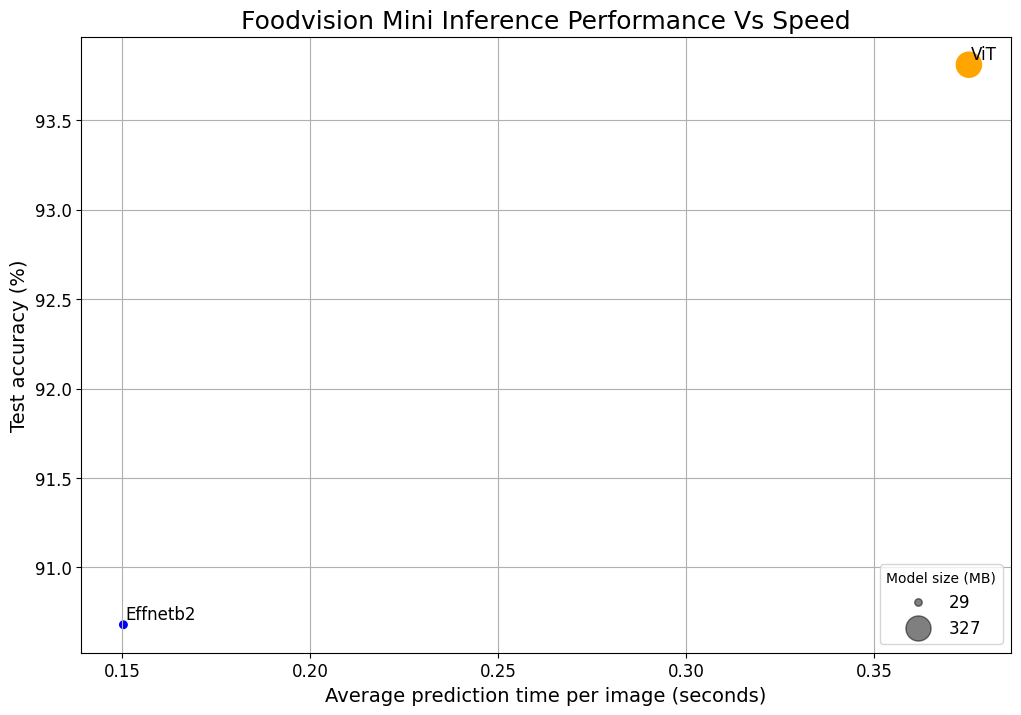

In [55]:
fig, ax = plt.subplots(figsize=(12,8))
scatter = ax.scatter(data=df,
                     x="time_per_pred_cpu",
                     y="test_acc",
                     c=["blue", "orange"],
                     s="model_size (MB)")

ax.set_title("Foodvision Mini Inference Performance Vs Speed", fontsize=18)
ax.set_xlabel("Average prediction time per image (seconds)", fontsize=14)
ax.set_ylabel("Test accuracy (%)", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.grid(True)

for index, row in df.iterrows():
    ax.annotate(text=row["model"],
                xy=(row["time_per_pred_cpu"]+0.0006, row["test_acc"]+0.03),
                size=12)
    print(row, index)

handles, labels = scatter.legend_elements(prop="sizes", alpha=0.5)
model_size_legend = ax.legend(handles, 
                              labels, 
                              loc="lower right", 
                              title="Model size (MB)",
                              fontsize=12)

# Save the figure
!mdkir images/
plt.savefig("../images/09-foodvision-mini-inference-speed-vs-performance.jpg")

# Show the figure
plt.show()

## 7. Using Gradio to Deploy our Model
(Date - 9/Aug/2026)

In [56]:
try:
    import gradio as gr
except:
    !pip -q install gradio
    import gradio as gr

print(f"Gradio version: {gr.__version__}")

Gradio version: 6.22.0


### 7.1 Creating a function to map our inputs and outputs
(Date - 10/Aug/2026)

In [57]:
effnetb2.to(device)
next(iter(effnetb2.parameters())).device

device(type='cpu')

In [58]:
def predict(img) -> Tuple[Dict, float]:
    """
    Transforms an image and makes a prediction. It returns the predicted probability and time taken to make the prediction.
    """

    start_timer = timer()
    img = effnetb2_transforms(img).unsqueeze(0)

    effnetb2.eval()
    with torch.inference_mode():
        pred_probs = torch.softmax(effnetb2(img), dim=1)

    pred_labels_and_probs = {class_names[i] : pred_probs[0][i] for i in range(len(class_names))}
    pred_time = round(timer() - start_timer, 5)

    return pred_labels_and_probs, pred_time

In [59]:
test_data_paths = list(Path(test_dir).glob("*/*.jpg"))

random_path = random.choice(test_data_paths)

random_image = Image.open(random_path)

pred_prob, time_taken = predict(random_image)
print(f"Prediction labels and probabilities:\n{pred_prob}\n\nTime taken (seconds): {time_taken}")

Prediction labels and probabilities:
{'pizza': tensor(0.2009), 'steak': tensor(0.5251), 'sushi': tensor(0.2740)}

Time taken (seconds): 0.20742


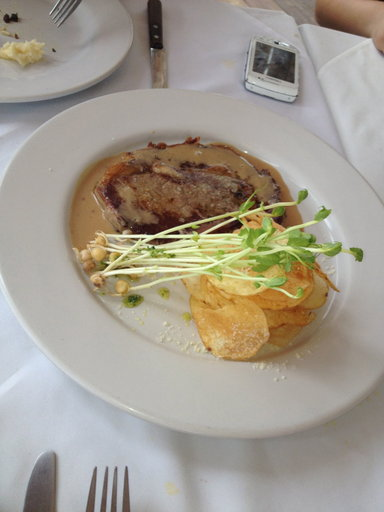

In [60]:
random_image

### 7.2 Creating a list of example images
(Date - 11/Aug/2026)

In [61]:
# Create a list of example inputs to our Gradio demo
example_list = [[str(filepath)] for filepath in random.sample(test_data_paths, k=3)]
example_list

[['data\\pizza_steak_sushi_20_percent\\test\\sushi\\3401466.jpg'],
 ['data\\pizza_steak_sushi_20_percent\\test\\sushi\\715227.jpg'],
 ['data\\pizza_steak_sushi_20_percent\\test\\pizza\\3497151.jpg']]

### 7.3 Building a Gradio interface

In [62]:
title = "FoodVision Mini 🍕🥩🍣"
description = "An EfficientNetB2 feature extractor to classify an image into pizza, sushi or steak"
article = "Created at [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/)."

demo = gr.Interface(fn=predict,
                    inputs=gr.Image(type="pil"),
                    outputs=[gr.Label(num_top_classes=3, label="predictions"),
                             gr.Number(label="Prediction time (seconds)")],
                    examples=example_list,
                    title=title,
                    description=description,
                    article=article
)

demo.launch(debug=False,
            share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://fe328e490aed079a8e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 8. Turning our FoodVision Mini Gradio Demo into a deployable app
(Date - 12/Aug/2026)

### 8.1 Creating a demos folder to store our FoodVision Mini app files

In [63]:
foodvision_mini_path = Path("../36.ipynb/demos/foodvision_mini/")

if foodvision_mini_path.exists():
    shutil.rmtree(foodvision_mini_path)

foodvision_mini_path.mkdir(parents=True, exist_ok=True)

!ls demos/foodvision_mini/ 

'ls' is not recognized as an internal or external command,
operable program or batch file.


### 8.2 Creating a folder with example images

In [64]:
example_images_folder = Path("../36.ipynb/demos/foodvision_mini/example_images/")

if example_images_folder.exists():
    shutil.rmtree(example_images_folder)

example_images_folder.mkdir(parents=True, exist_ok=True)

for i in range(3):
    img = random.choice(test_data_paths)
    shutil.copy(img, example_images_folder)

### 8.3 Moving our EffnetB2 trained model to the demos folder

In [65]:
demo_model_path = "../models/9_effnetb2_feature_extractor.pth"
shutil.copy(demo_model_path, foodvision_mini_path)

'..\\36.ipynb\\demos\\foodvision_mini\\9_effnetb2_feature_extractor.pth'

### 8.4 Turning our EffnetB2 model into a python script

In [66]:
%%writefile demos/foodvision_mini/model.py
import torch
import torchvision
from torch import nn

def EffnetB2_creator(num_classes:int=3,
                    seed:int=42):
    """Creates an EfficientNetB2 feature extractor model and transforms.

    Args:
        num_classes (int, optional): number of classes in the classifier head. 
            Defaults to 3.
        seed (int, optional): random seed value. Defaults to 42.

    Returns:
        model (torch.nn.Module): EffNetB2 feature extractor model. 
        transforms (torchvision.transforms): EffNetB2 image transforms.
    """
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.efficientnet_b2(weights=weights)

    for param in model.parameters():
        param.requires_grad = False
    
    torch.manual_seed(seed)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features=1408,
                  out_features=num_classes)
    )

    return model, transforms

Writing demos/foodvision_mini/model.py


### 8.5 Turning our FoodVision Mini Gradio app into a Python script (app.py)
(Date - 13/Aug/2026)

In [67]:
%%writefile demos/foodvision_mini/app.py
import torch
import os
import gradio as gr

from typing import Tuple, Dict
from model import Effnetb2_creator
from timeit import default_timer as timer

class_names = ["pizza", "steak", "sushi"]

effnetb2, effnetb2_transforms = Effnetb2_creator(num_classes=3)

effnetb2.load_state_dict(
    torch.load(
        f="../models/9_effnetb2_feature_extractor.pth",
        map_location=torch.device("cpu")
    )
)

def predict(img) -> Tuple[Dict, float]:
    """
    Transforms an image and makes a prediction. It returns the predicted probability and time taken to make the prediction.
    """

    start_timer = timer()
    img = effnetb2_transforms(img).unsqueeze(0)

    effnetb2.eval()
    with torch.inference_mode():
        pred_probs = torch.softmax(effnetb2(img), dim=1)

    pred_labels_and_probs = {class_names[i] : pred_probs[0][i] for i in range(len(class_names))}
    pred_time = round(timer() - start_timer, 5)

    return pred_labels_and_probs, pred_time

title = "FoodVision Mini 🍕🥩🍣"
description = "An EfficientNetB2 feature extractor to classify an image into pizza, sushi or steak"
article = "Created at [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/)."

demo = gr.Interface(fn=predict,
                    inputs=gr.Image(type="pil"),
                    outputs=[gr.Label(num_top_classes=3, label="predictions"),
                             gr.Number(label="Prediction time (seconds)")],
                    examples=example_list,
                    title=title,
                    description=description,
                    article=article
)

demo.launch()

Writing demos/foodvision_mini/app.py


### 8.6 Creating a requirements file
(Date - 14/Aug/2026)

In [68]:
%%writefile demos/foodvision_mini/requirements.txt
torch==1.12.0
torchvision==0.13.0
gradio==3.1.4

Writing demos/foodvision_mini/requirements.txt


## 9. Deploying our FoodVision Mini app to HuggingFace Spaces

In [69]:
IFrame(
    src="https://VyomX007-Foodvision-mini.hf.space",
    width=800,
    height=600
)

## 10. Creating Foodvision Big
(Date - 15/Aug/2026)

### 10.1 Creating a model and transforms for Foodvision Big

In [70]:
effnetb2_food101, effnetb2_transforms = create_effnetb2(num_classes=101)

In [71]:
summary(effnetb2_food101, 
        input_size=(1, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 101]             --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

In [72]:
Food101_train_transforms = torchvision.transforms.Compose([
    torchvision.transforms.TrivialAugmentWide(),
    effnetb2_transforms
])

In [73]:
print(f"Training transforms:\n {torchvision.transforms.TrivialAugmentWide()}\n")
print(f"Testing transforms:\n {effnetb2_transforms}\n")

Training transforms:
 TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)

Testing transforms:
 ImageClassification(
    crop_size=[288]
    resize_size=[288]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)



### 10.2 Getting data for FoodVision Big
(Date - 16/Aug/2026)

In [74]:
data_dir = Path("data")

train_data = datasets.Food101(root=data_dir,
                              split="train",
                              download=True,
                              transform=Food101_train_transforms)

test_data = datasets.Food101(root=data_dir,
                             split="test",
                             download=True,
                             transform=effnetb2_transforms)

In [75]:
food101_class_names = train_data.classes
food101_class_names

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito',
 'bruschetta',
 'caesar_salad',
 'cannoli',
 'caprese_salad',
 'carrot_cake',
 'ceviche',
 'cheese_plate',
 'cheesecake',
 'chicken_curry',
 'chicken_quesadilla',
 'chicken_wings',
 'chocolate_cake',
 'chocolate_mousse',
 'churros',
 'clam_chowder',
 'club_sandwich',
 'crab_cakes',
 'creme_brulee',
 'croque_madame',
 'cup_cakes',
 'deviled_eggs',
 'donuts',
 'dumplings',
 'edamame',
 'eggs_benedict',
 'escargots',
 'falafel',
 'filet_mignon',
 'fish_and_chips',
 'foie_gras',
 'french_fries',
 'french_onion_soup',
 'french_toast',
 'fried_calamari',
 'fried_rice',
 'frozen_yogurt',
 'garlic_bread',
 'gnocchi',
 'greek_salad',
 'grilled_cheese_sandwich',
 'grilled_salmon',
 'guacamole',
 'gyoza',
 'hamburger',
 'hot_and_sour_soup',
 'hot_dog',
 'huevos_rancheros',
 'hummus',
 'ice_cream',
 'lasagna',
 'lobster_bisque',
 'lobster

### 10.3 Creating a subset of Food101 dataset for fast experimenting
(Date - 17/Aug/2026)

In [76]:
def split_dataset(dataset:torchvision.datasets,
                  split_size:float=0.2,
                  seed:int=42):
    """Randomly splits a given dataset into two proportions based on split_size and seed.

    Args:
        dataset (torchvision.datasets): A PyTorch Dataset, typically one from torchvision.datasets.
        split_size (float, optional): How much of the dataset should be split? 
            E.g. split_size=0.2 means there will be a 20% split and an 80% split. Defaults to 0.2.
        seed (int, optional): Seed for random generator. Defaults to 42.

    Returns:
        tuple: (random_split_1, random_split_2) where random_split_1 is of size split_size*len(dataset) and 
            random_split_2 is of size (1-split_size)*len(dataset).
    """
    length_1 = int(len(dataset) * split_size)
    length_2 = len(dataset) - length_1

    print(f"[INFO] Splitting the dataset of length {len(dataset)} into {length_1} ({int(split_size*100)}%), {length_2} ({int((1-split_size)*100)}%)")

    random_split_1, random_split_2 = torch.utils.data.random_split(dataset=dataset,
                                                                   lengths=[length_1, length_2],
                                                                   generator=torch.manual_seed(seed))
    return random_split_1, random_split_2


In [77]:
train_data_food101_20, _ = split_dataset(dataset=train_data,
                                      split_size=0.2)
test_data_food101_20, _ = split_dataset(dataset=test_data,
                                     split_size=0.2)

len(train_data_food101_20), len(test_data_food101_20)

[INFO] Splitting the dataset of length 75750 into 15150 (20%), 60600 (80%)
[INFO] Splitting the dataset of length 25250 into 5050 (20%), 20200 (80%)


(15150, 5050)

### 10.4 Turning our Food101 datasets into DataLoaders

In [78]:
train_dataloader_food101_20 = torch.utils.data.DataLoader(dataset=train_data_food101_20,
                                                          shuffle=True,
                                                          batch_size=32,
                                                          num_workers=True)

test_dataloader_food101_20 = torch.utils.data.DataLoader(dataset=test_data_food101_20,
                                                         shuffle=True,
                                                         batch_size=32,
                                                         num_workers=2)

test_dataloader_food101_20, train_dataloader_food101_20

(<torch.utils.data.dataloader.DataLoader at 0x1d5f9908250>,
 <torch.utils.data.dataloader.DataLoader at 0x1d5fc29bb10>)

### 10.5 Time for Training!

In [79]:
optimizer = torch.optim.Adam(params=effnetb2_food101.parameters(),
                             lr=1e-3)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

food101_20_results = engine.train(train_dataloader=train_dataloader_food101_20,
                                  test_dataloader=test_dataloader_food101_20,
                                  loss_fn=loss_fn,
                                  optimizer=optimizer,
                                  model=effnetb2_food101,
                                  epochs=1,
                                  device=device)

100%|██████████| 1/1 [44:13<00:00, 2653.49s/it]

Epoch: 1 | train_loss: 3.6377 | train_acc: 0.2821 | test_loss: 2.7921 | test_acc: 0.4861


### 10.6 plotting the loss curves

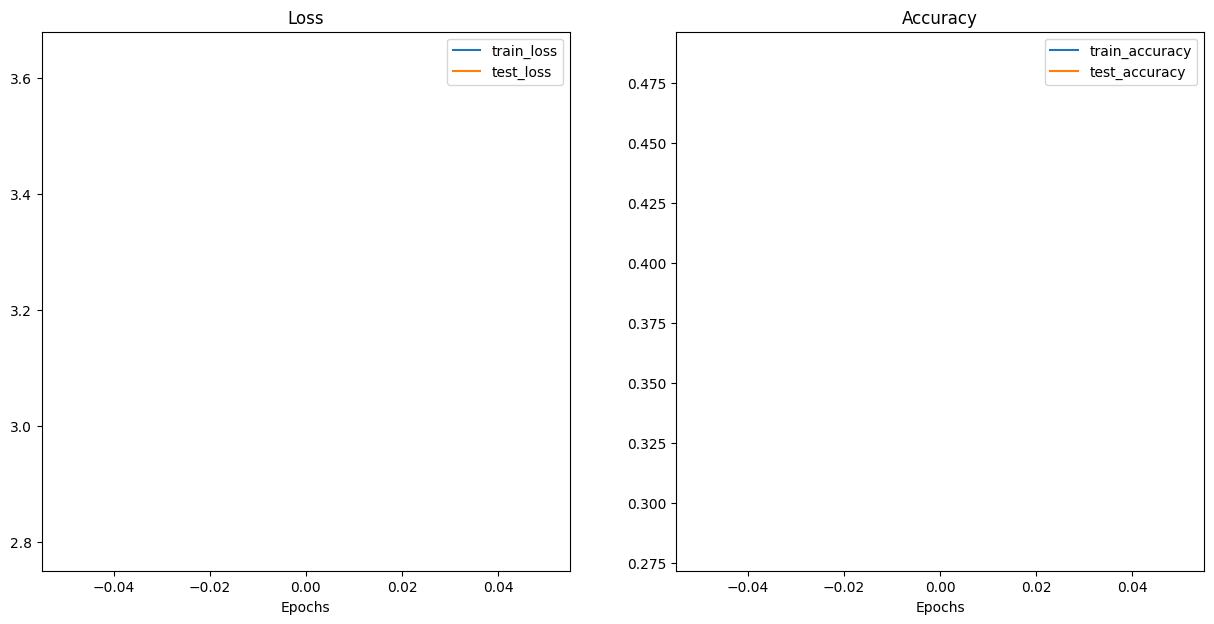

In [80]:
plot_loss_curves(food101_20_results)

### 10.7 Saving and Loading Food101 Big

In [81]:
food101_20_path = "09_Food101_20_percent.pth"

utils.save_model(model=effnetb2_food101,
                target_dir= "../models",
                model_name=food101_20_path)

[INFO] Saving model to: ..\models\09_Food101_20_percent.pth


In [85]:
loaded_effnetb2_food101, effnetb2_transforms = create_effnetb2(num_classes=101)
loaded_effnetb2_food101.load_state_dict(torch.load("../models/09_Food101_20_percent.pth"))

<All keys matched successfully>

### 10.8 Checking Food101 Big model size

In [88]:
food101_size = Path("../models/09_Food101_20_percent.pth").stat().st_size // 1024**2
print(f"Food101 Big model size (MB): {food101_size}")

Food101 Big model size (MB): 30


## 11. Turning our FoodVision Big into a Deployable app
(Date - 18/Aug/2026)

In [89]:
foodvision_big_demo_path = Path("../36.ipynb/demos/foodvision_big")
foodvision_big_demo_path.mkdir(parents=True, exist_ok=True)
(foodvision_big_demo_path / "examples").mkdir(parents=True, exist_ok=True)

### 11.1 Saving Food101 class names to class_names.txt
(Date - 19/Aug/2026)

In [90]:
food101_class_names

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito',
 'bruschetta',
 'caesar_salad',
 'cannoli',
 'caprese_salad',
 'carrot_cake',
 'ceviche',
 'cheese_plate',
 'cheesecake',
 'chicken_curry',
 'chicken_quesadilla',
 'chicken_wings',
 'chocolate_cake',
 'chocolate_mousse',
 'churros',
 'clam_chowder',
 'club_sandwich',
 'crab_cakes',
 'creme_brulee',
 'croque_madame',
 'cup_cakes',
 'deviled_eggs',
 'donuts',
 'dumplings',
 'edamame',
 'eggs_benedict',
 'escargots',
 'falafel',
 'filet_mignon',
 'fish_and_chips',
 'foie_gras',
 'french_fries',
 'french_onion_soup',
 'french_toast',
 'fried_calamari',
 'fried_rice',
 'frozen_yogurt',
 'garlic_bread',
 'gnocchi',
 'greek_salad',
 'grilled_cheese_sandwich',
 'grilled_salmon',
 'guacamole',
 'gyoza',
 'hamburger',
 'hot_and_sour_soup',
 'hot_dog',
 'huevos_rancheros',
 'hummus',
 'ice_cream',
 'lasagna',
 'lobster_bisque',
 'lobster

In [91]:
food_vision_class_names_path = foodvision_big_demo_path / "class_names.txt"

with open(food_vision_class_names_path, "w") as f:
    print(f"[INFO] Saving FoodVision class names to: {food_vision_class_names_path}")
    f.write("\n".join(food101_class_names))

[INFO] Saving FoodVision class names to: ..\36.ipynb\demos\foodvision_big\class_names.txt


In [92]:
with open(food_vision_class_names_path, "r") as f:
    food_vision_class_names_loaded = [food.strip() for food in f.readlines()]

food_vision_class_names_loaded[:5]

['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare']

### 11.2. Turning our FoodVision Big into a python script `(model.py)`

In [93]:
%%writefile demos/foodvision_big/model.py
import torch
import torchvision

from torch import nn


def create_effnetb2_model(num_classes:int=3, 
                          seed:int=42):
    """Creates an EfficientNetB2 feature extractor model and transforms.

    Args:
        num_classes (int, optional): number of classes in the classifier head. 
            Defaults to 3.
        seed (int, optional): random seed value. Defaults to 42.

    Returns:
        model (torch.nn.Module): EffNetB2 feature extractor model. 
        transforms (torchvision.transforms): EffNetB2 image transforms.
    """
    # Create EffNetB2 pretrained weights, transforms and model
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.efficientnet_b2(weights=weights)

    # Freeze all layers in base model
    for param in model.parameters():
        param.requires_grad = False

    # Change classifier head with random seed for reproducibility
    torch.manual_seed(seed)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features=1408, out_features=num_classes),
    )
    
    return model, transforms

Writing demos/foodvision_big/model.py


### 11.3. Turning our FoodVision Big Gradio app into a python script `(app.py)`

In [94]:
%%writefile demos/foodvision_big/app.py
### 1. Imports and class names setup ### 
import gradio as gr
import os
import torch

from model import create_effnetb2_model
from timeit import default_timer as timer
from typing import Tuple, Dict

# Setup class names
with open("class_names.txt", "r") as f: # reading them in from class_names.txt
    class_names = [food_name.strip() for food_name in  f.readlines()]
    
### 2. Model and transforms preparation ###    

# Create model
effnetb2, effnetb2_transforms = create_effnetb2_model(
    num_classes=101, # could also use len(class_names)
)

# Load saved weights
effnetb2.load_state_dict(
    torch.load(
        f="09_pretrained_effnetb2_feature_extractor_food101_20_percent.pth",
        map_location=torch.device("cpu"),  # load to CPU
    )
)

### 3. Predict function ###

# Create predict function
def predict(img) -> Tuple[Dict, float]:
    """Transforms and performs a prediction on img and returns prediction and time taken.
    """
    # Start the timer
    start_time = timer()
    
    # Transform the target image and add a batch dimension
    img = effnetb2_transforms(img).unsqueeze(0)
    
    # Put model into evaluation mode and turn on inference mode
    effnetb2.eval()
    with torch.inference_mode():
        # Pass the transformed image through the model and turn the prediction logits into prediction probabilities
        pred_probs = torch.softmax(effnetb2(img), dim=1)
    
    # Create a prediction label and prediction probability dictionary for each prediction class (this is the required format for Gradio's output parameter)
    pred_labels_and_probs = {class_names[i]: float(pred_probs[0][i]) for i in range(len(class_names))}
    
    # Calculate the prediction time
    pred_time = round(timer() - start_time, 5)
    
    # Return the prediction dictionary and prediction time 
    return pred_labels_and_probs, pred_time

### 4. Gradio app ###

# Create title, description and article strings
title = "FoodVision Big 🍔👁"
description = "An EfficientNetB2 feature extractor computer vision model to classify images of food into [101 different classes](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/food101_class_names.txt)."
article = "Created at [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/)."

# Create examples list from "examples/" directory
example_list = [["examples/" + example] for example in os.listdir("examples")]

# Create Gradio interface 
demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=[
        gr.Label(num_top_classes=5, label="Predictions"),
        gr.Number(label="Prediction time (s)"),
    ],
    examples=example_list,
    title=title,
    description=description,
    article=article,
)

# Launch the app!
demo.launch()

Writing demos/foodvision_big/app.py


### 11.4. Creating a requirements file `(requirements.txt)`

In [95]:
%%writefile demos/foodvision_big/requirements.txt
torch==1.12.0
torchvision==0.13.0
gradio==3.1.4

Writing demos/foodvision_big/requirements.txt
